In [16]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

In [17]:
host_trust = pd.read_csv("../Data/HostTrust_Output.csv")[
    ["listing_id", "HostTrust", "HostTrust_Components_Used", "review_scores_rating"]
]
listing_iq = pd.read_csv("../Data/ListingIQ_Output.csv")[
    ["listing_id", "ListingIQ", "ListingIQ_Components_Used"]
]
experience_iq = pd.read_csv("../Data/ExperienceIQ_Output.csv")[
    ["listing_id", "ExperienceIQ"]
]

master = (
    host_trust
    .merge(listing_iq, on="listing_id", how="left")
    .merge(experience_iq, on="listing_id", how="left")
)

print(master.shape)
master.head()

(279434, 7)


,listing_id,HostTrust,HostTrust_Components_Used,review_scores_rating,ListingIQ,ListingIQ_Components_Used,ExperienceIQ
0,281420,45.477167,3,100.0,21.812885,5.0,100.0
1,3705183,42.189042,3,100.0,22.830290,5.0,100.0
2,4082273,32.385460,3,100.0,22.152020,5.0,100.0
3,4797344,41.946353,3,100.0,21.812885,5.0,100.0
4,4823489,30.551812,3,100.0,24.186830,5.0,100.0


In [18]:
master.info()
master.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279434 entries, 0 to 279433
Data columns (total 7 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   listing_id                 279434 non-null  int64  
 1   HostTrust                  279434 non-null  float64
 2   HostTrust_Components_Used  279434 non-null  int64  
 3   review_scores_rating       188199 non-null  float64
 4   ListingIQ                  279433 non-null  float64
 5   ListingIQ_Components_Used  279433 non-null  float64
 6   ExperienceIQ               187812 non-null  float64
dtypes: float64(5), int64(2)
memory usage: 14.9 MB


,listing_id,HostTrust,HostTrust_Components_Used,review_scores_rating,ListingIQ,ListingIQ_Components_Used,ExperienceIQ
count,2.794340e+05,279434.000000,279434.000000,188199.000000,279433.000000,279433.000000,187812.000000
mean,2.637677e+07,29.080200,4.676149,93.405395,29.379194,4.895009,93.356013
std,1.442383e+07,14.156633,1.370729,10.070857,6.360351,0.306543,11.473643
min,2.577000e+03,0.013483,3.000000,20.000000,2.632232,4.000000,0.000000
25%,1.384404e+07,17.985930,3.000000,91.000000,24.710910,5.000000,91.307500
50%,2.766007e+07,28.328820,5.000000,96.000000,28.672754,5.000000,100.000000
75%,3.977787e+07,38.272440,6.000000,100.000000,33.004341,5.000000,100.000000
max,4.834353e+07,95.955188,6.000000,100.000000,79.359506,5.000000,100.000000


In [19]:
master["KPIs_Available"] = (
    master[
        ["HostTrust","ListingIQ","ExperienceIQ"]
    ]
    .notna()
    .sum(axis=1)
)

master["KPIs_Available"].value_counts().sort_index()

KPIs_Available
1         1
2     91621
3    187812
Name: count, dtype: int64

In [20]:
master["KPI_Combination"] = (
    master[
        ["HostTrust","ListingIQ","ExperienceIQ"]
    ]
    .notna()
    .astype(int)
    .astype(str)
    .agg("".join, axis=1)
)

master["KPI_Combination"].value_counts()

KPI_Combination
111    187812
110     91621
100         1
Name: count, dtype: int64

In [21]:
master[
    ["HostTrust", "ListingIQ", "ExperienceIQ", "review_scores_rating"]
].corr()

,HostTrust,ListingIQ,ExperienceIQ,review_scores_rating
HostTrust,1.000000,0.095753,0.195373,0.197148
ListingIQ,0.095753,1.000000,0.086177,0.079928
ExperienceIQ,0.195373,0.086177,1.000000,0.821373
review_scores_rating,0.197148,0.079928,0.821373,1.000000


In [22]:
master.isna().sum()

listing_id                       0
HostTrust                        0
HostTrust_Components_Used        0
review_scores_rating         91235
ListingIQ                        1
ListingIQ_Components_Used        1
ExperienceIQ                 91622
KPIs_Available                   0
KPI_Combination                  0
dtype: int64

In [23]:
master

,listing_id,HostTrust,HostTrust_Components_Used,review_scores_rating,ListingIQ,ListingIQ_Components_Used,ExperienceIQ,KPIs_Available,KPI_Combination
0,281420,45.477167,3,100.0,21.812885,5.0,100.0,3,111
1,3705183,42.189042,3,100.0,22.830290,5.0,100.0,3,111
2,4082273,32.385460,3,100.0,22.152020,5.0,100.0,3,111
3,4797344,41.946353,3,100.0,21.812885,5.0,100.0,3,111
4,4823489,30.551812,3,100.0,24.186830,5.0,100.0,3,111
...,...,...,...,...,...,...,...,...,...
279429,38338635,35.447689,3,100.0,24.186830,5.0,100.0,3,111
279430,38538692,42.216007,3,100.0,24.186830,5.0,100.0,3,111
279431,38683356,50.022494,3,100.0,25.204235,5.0,100.0,3,111
279432,39659000,34.180314,3,100.0,25.204235,5.0,100.0,3,111


In [24]:
weight_map = {
    "HostTrust": 1/3,
    "ListingIQ": 1/3,
    "ExperienceIQ": 1/3
}

master["StayScore"] = (
    master["HostTrust"] * weight_map["HostTrust"] +
    master["ListingIQ"] * weight_map["ListingIQ"] +
    master["ExperienceIQ"] * weight_map["ExperienceIQ"]
)


In [26]:
master['StayScore'].describe()

count    187812.000000
mean         51.732933
std           7.148842
min           6.248268
25%          47.589070
50%          51.844308
75%          56.331217
max          77.414176
Name: StayScore, dtype: float64

In [27]:
print("Missing StayScore:", master["StayScore"].isna().sum())

Missing StayScore: 91622


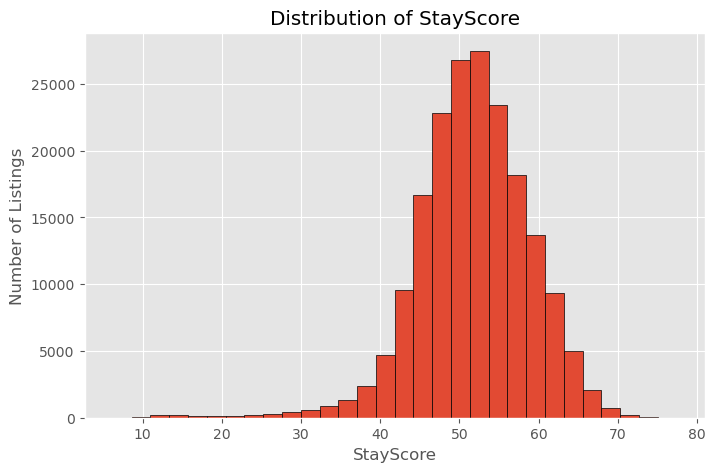

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    master["StayScore"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of StayScore")
plt.xlabel("StayScore")
plt.ylabel("Number of Listings")

plt.show()

In [29]:
master["StayScore_Group"] = pd.qcut(
    master["StayScore"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [30]:
stayscore_validation = (
    master
    .groupby("StayScore_Group")["review_scores_rating"]
    .agg(["count", "mean", "median", "std"])
)

stayscore_validation

,count,mean,median,std
StayScore_Group,,,,
Very Low,37557,84.615012,89.0,17.003759
Low,37555,93.621702,95.0,6.873244
Medium,37556,95.167643,96.0,5.624192
High,37555,96.365437,98.0,4.556547
Very High,37561,97.300019,98.0,3.158892


In [31]:
master

,listing_id,HostTrust,HostTrust_Components_Used,review_scores_rating,ListingIQ,ListingIQ_Components_Used,ExperienceIQ,KPIs_Available,KPI_Combination,StayScore,StayScore_Group
0,281420,45.477167,3,100.0,21.812885,5.0,100.0,3,111,55.763351,High
1,3705183,42.189042,3,100.0,22.830290,5.0,100.0,3,111,55.006444,High
2,4082273,32.385460,3,100.0,22.152020,5.0,100.0,3,111,51.512493,Medium
3,4797344,41.946353,3,100.0,21.812885,5.0,100.0,3,111,54.586413,High
4,4823489,30.551812,3,100.0,24.186830,5.0,100.0,3,111,51.579547,Medium
...,...,...,...,...,...,...,...,...,...,...,...
279429,38338635,35.447689,3,100.0,24.186830,5.0,100.0,3,111,53.211506,Medium
279430,38538692,42.216007,3,100.0,24.186830,5.0,100.0,3,111,55.467612,High
279431,38683356,50.022494,3,100.0,25.204235,5.0,100.0,3,111,58.408910,Very High
279432,39659000,34.180314,3,100.0,25.204235,5.0,100.0,3,111,53.128183,Medium


In [32]:
master.rename(
    columns={"KPIs_Available": "Available_Pillars"},
    inplace=True
)

In [36]:
stayscore_output = master[
    [
        "listing_id",
        "HostTrust",
        "HostTrust_Components_Used",
        "ListingIQ",
        "ListingIQ_Components_Used",
        "ExperienceIQ",
        "Available_Pillars",
        "StayScore",
        "StayScore_Group",
        "review_scores_rating"

    ]
].copy()

In [37]:
stayscore_output.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279434 entries, 0 to 279433
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   listing_id                 279434 non-null  int64   
 1   HostTrust                  279434 non-null  float64 
 2   HostTrust_Components_Used  279434 non-null  int64   
 3   ListingIQ                  279433 non-null  float64 
 4   ListingIQ_Components_Used  279433 non-null  float64 
 5   ExperienceIQ               187812 non-null  float64 
 6   Available_Pillars          279434 non-null  int64   
 7   StayScore                  187812 non-null  float64 
 8   StayScore_Group            187812 non-null  category
 9   review_scores_rating       188199 non-null  float64 
dtypes: category(1), float64(6), int64(3)
memory usage: 19.5 MB


In [38]:
stayscore_output.head()

,listing_id,HostTrust,HostTrust_Components_Used,ListingIQ,ListingIQ_Components_Used,ExperienceIQ,Available_Pillars,StayScore,StayScore_Group,review_scores_rating
0,281420,45.477167,3,21.812885,5.0,100.0,3,55.763351,High,100.0
1,3705183,42.189042,3,22.830290,5.0,100.0,3,55.006444,High,100.0
2,4082273,32.385460,3,22.152020,5.0,100.0,3,51.512493,Medium,100.0
3,4797344,41.946353,3,21.812885,5.0,100.0,3,54.586413,High,100.0
4,4823489,30.551812,3,24.186830,5.0,100.0,3,51.579547,Medium,100.0


In [39]:
stayscore_output.to_csv(
    "../Data/StayScore_Output.csv",
    index=False
)